In [1]:
import pandas as pd
import pyarrow.parquet as pq
from tqdm import tqdm

cols = ['customer_id', 'event_type', 'cost', 'sales', 'timestamp_utc']
parquet_file = pq.ParquetFile('data/customer_journey.parquet')

# Étape 1 : On doit d'abord identifier la 1ère exposition par utilisateur sur TOUT le fichier
# car la 1ère expo peut être dans le batch 1 et une vente dans le batch 10.
print("Recherche des dates de première exposition...")
user_first_expo = {}

for batch in tqdm(parquet_file.iter_batches(batch_size=500_000, columns=['customer_id', 'event_type', 'timestamp_utc'])):
    chunk = batch.to_pandas()
    exposures = chunk[chunk['event_type'] == 'exposure']
    if not exposures.empty:
        # On trouve le min par batch
        batch_min = exposures.groupby('customer_id')['timestamp_utc'].min()
        # On met à jour le dictionnaire global si le nouveau min est plus ancien
        for cid, t in batch_min.items():
            if cid not in user_first_expo or t < user_first_expo[cid]:
                user_first_expo[cid] = t

# On transforme le dictionnaire en Series pour une jointure rapide
df_first_expo = pd.Series(user_first_expo, name='first_exposure_ts')

# Étape 2 : Deuxième passage pour calculer les ventes (Total vs Post-Expo)
print("Calcul des revenus...")
aggregated_data = []

for batch in tqdm(parquet_file.iter_batches(batch_size=500_000, columns=cols)):
    chunk = batch.to_pandas()
    
    # On ramène la date de 1ère expo pour chaque ligne du chunk
    chunk = chunk.join(df_first_expo, on='customer_id')
    
    # --------------------------
    # SALES
    # --------------------------
    chunk['sales_total'] = chunk['sales'].fillna(0)
    
    # Post-exposure revenue (after first exposure)
    chunk['sales_post_expo'] = 0.0
    mask_post = (chunk['event_type'] != 'exposure') & \
                (chunk['sales'] > 0) & \
                (chunk['timestamp_utc'] > chunk['first_exposure_ts'])
    chunk.loc[mask_post, 'sales_post_expo'] = chunk.loc[mask_post, 'sales']
    
    # Pre-exposure revenue (for DiD)
    chunk['sales_pre_expo'] = 0.0
    mask_pre = (chunk['event_type'] != 'exposure') & \
               (chunk['sales'] > 0) & \
               (chunk['timestamp_utc'] <= chunk['first_exposure_ts'])
    chunk.loc[mask_pre, 'sales_pre_expo'] = chunk.loc[mask_pre, 'sales']
    
    # Control revenue (users with no exposure)
    chunk['sales_control'] = 0.0
    mask_control = chunk['event_type'] != 'exposure'
    mask_control &= chunk['first_exposure_ts'].isna()  # no exposure
    mask_control &= chunk['sales'] > 0
    chunk.loc[mask_control, 'sales_control'] = chunk.loc[mask_control, 'sales']
    

    # Optional: compute delay_days as before
    test = chunk[
        (chunk['sales'] > 0) &
        (chunk['first_exposure_ts'].notna())
    ].copy()
    test['delay_days'] = (test['timestamp_utc'] - test['first_exposure_ts']).dt.days

    # --------------------------
    # GROUP BY USER
    # --------------------------
    summary = chunk.groupby('customer_id').agg({
        'sales_total': 'sum',
        'sales_pre_expo': 'sum',       # NEW
        'sales_post_expo': 'sum',
        'sales_control': 'sum',        # NEW
        'cost': 'sum',
        'event_type': lambda x: (x == 'exposure').sum()
    })
    
    aggregated_data.append(summary)

# Fusion finale
user_metrics = pd.concat(aggregated_data).groupby(level=0).sum().reset_index()
user_metrics.rename(columns={'event_type': 'nb_impressions', 'cost': 'budget_media_raw'}, inplace=True)
user_metrics['budget_media'] = user_metrics['budget_media_raw'] / 100000

Recherche des dates de première exposition...


59it [00:28,  2.09it/s]


Calcul des revenus...


59it [11:57, 12.16s/it]


In [2]:
# ==============================
# STEP 4 — GLOBAL KPIs
# ==============================
total_sales = user_metrics['sales_total'].sum()
total_sales_post_expo = user_metrics['sales_post_expo'].sum()
total_budget = user_metrics['budget_media'].sum()

roas = total_sales / total_budget if total_budget > 0 else 0

# PROAS → only budget from users who generated post-expo sales
post_expo_budget = user_metrics[
    user_metrics['sales_post_expo'] > 0
]['budget_media'].sum()

proas = (
    total_sales_post_expo / total_budget
    if post_expo_budget > 0 else 0
)

print("\n--- Performance Report ($) ---")
print(f"Total Budget : ${total_budget:,.2f}")
print(f"Total Sales : ${total_sales:,.2f}")
print(f"Post-Exposure Sales : ${total_sales_post_expo:,.2f}")
print("--------------------------------")
print(f"ROAS : {roas:.2f}x")
print(f"Post-Exposure ROAS : {proas:.2f}x")


--- Performance Report ($) ---
Total Budget : $193,603.35
Total Sales : $61,193,480.00
Post-Exposure Sales : $22,274,509.64
--------------------------------
ROAS : 316.08x
Post-Exposure ROAS : 115.05x


In [3]:
# === IROAS ===
df_exposed = user_metrics[user_metrics['nb_impressions'] > 0]
df_control = user_metrics[user_metrics['nb_impressions'] == 0]

rev_per_user_exposed = df_exposed['sales_total'].mean()
rev_per_user_control = df_control['sales_total'].mean()

incremental_rev_per_user = (
    rev_per_user_exposed - rev_per_user_control
)

incremental_revenue = incremental_rev_per_user * len(df_exposed)

incremental_roas = incremental_revenue / total_budget

print(f'iROAS: {incremental_roas}')

# CAUTION: Assumes exposed VS non-exposed client are identical in intent !!!

iROAS: -1342.4930666736054


In [4]:
# Sanity checks

print("Exposed users:", len(df_exposed))
print("Control users:", len(df_control))

print("Mean revenue exposed:", df_exposed['sales_total'].mean())
print("Mean revenue control:", df_control['sales_total'].mean())

print("Total spend ($):", total_budget)

incremental_revenue = (
    df_exposed['sales_total'].sum()
    - len(df_exposed) * df_control['sales_total'].mean()
)

print("Incremental revenue ($):", incremental_revenue)


Exposed users: 6350654
Control users: 598715
Mean revenue exposed: 5.279626
Mean revenue control: 46.2063
Total spend ($): 193603.34772082
Incremental revenue ($): -2.5991115e+08


In [5]:
# === Difference in difference iROAS estimator ===

delta_exposed = (df_exposed['sales_post_expo'] - df_exposed['sales_pre_expo']).mean()
delta_control = df_control['sales_control'].mean()

incremental_rev_per_user = delta_exposed - delta_control
incremental_revenue = incremental_rev_per_user * len(df_exposed)

total_spend = df_exposed['budget_media'].sum()
did_iroas = incremental_revenue / total_spend

print("DiD Incremental Revenue ($):", round(incremental_revenue, 2))
print("DiD iROAS:", round(did_iroas, 3))

DiD Incremental Revenue ($): -282420277.6
DiD iROAS: -1458.757


In [16]:
# Example: 4 buckets by quantiles of impressions
# Define impression frequency buckets
# Adjust bins according to your data distribution
bins = [0, 1, 5, 20, 100, df_exposed['nb_impressions'].max()]
labels = ['1', '2-5', '5-20', '20-100', '100+']

df_exposed['impression_bucket'] = pd.cut(
    df_exposed['nb_impressions'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

bucket_results = []

for bucket in df_exposed['impression_bucket'].unique():
    df_bucket = df_exposed[df_exposed['impression_bucket'] == bucket]
    
    # Delta exposed (pre-post sales difference)
    delta_exposed = (df_bucket['sales_post_expo'] - df_bucket['sales_pre_expo']).mean()
    
    # Delta control (use same mean control as before, or optionally bucket control too)
    delta_control = df_control['sales_control'].mean()
    
    # Incremental revenue per user
    incremental_rev_per_user = delta_exposed - delta_control
    incremental_revenue = incremental_rev_per_user * len(df_bucket)
    
    # Total spend for this bucket
    total_spend = df_bucket['budget_media'].sum()
    
    # iROAS
    did_iroas = incremental_revenue / total_spend
    
    bucket_results.append({
        'bucket': bucket,
        'n_users': len(df_bucket),
        'incremental_revenue': incremental_revenue,
        'total_spend': total_spend,
        'iROAS': did_iroas
    })

bucket_df = pd.DataFrame(bucket_results)
print(bucket_df)


/tmp/ipykernel_5886/2712004428.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exposed['impression_bucket'] = pd.cut(


   bucket  n_users  incremental_revenue   total_spend        iROAS
0  20-100   106286        -4.092362e+06  26379.442501  -155.134515
1       1  3547612        -1.608363e+08  47068.964758 -3417.035603
2     2-5  1970735        -8.703251e+07  57630.113312 -1510.191604
3    5-20   725637        -3.044256e+07  62046.992115  -490.637210
4    100+      384        -1.651088e+04    477.835035   -34.553513


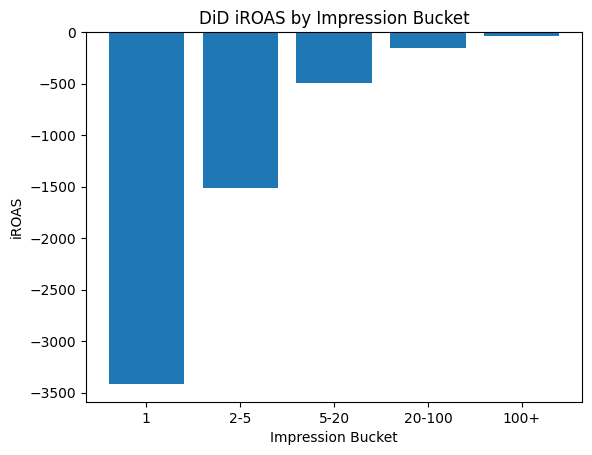

In [20]:
import matplotlib.pyplot as plt

bucket_df.sort_values(by='iROAS',inplace=True)

plt.bar(bucket_df['bucket'], bucket_df['iROAS'])
plt.xlabel('Impression Bucket')
plt.ylabel('iROAS')
plt.title('DiD iROAS by Impression Bucket')
plt.show()


In [6]:
# ==============================
# STEP 5 — CONVERSION METRICS
# ==============================
df_exposed = user_metrics[user_metrics['nb_impressions'] > 0]

nb_conversions = df_exposed[
    df_exposed['sales_post_expo'] > 0
]['customer_id'].nunique()

conversion_rate = (
    nb_conversions / len(df_exposed) * 100
    if len(df_exposed) > 0 else 0
)

exposed_budget = df_exposed['budget_media'].sum()

cpa = exposed_budget / nb_conversions if nb_conversions > 0 else 0

total_impressions = df_exposed['nb_impressions'].sum()
cpm = (exposed_budget / total_impressions) * 1000 if total_impressions > 0 else 0

print("\n--- Conversion Metrics ---")
print(f"Conversions (Post-Expo) : {nb_conversions}")
print(f"Conversion Rate : {conversion_rate:.2f}%")
print(f"CPA : ${cpa:.2f}")
print(f"CPM : ${cpm:.2f}")


--- Conversion Metrics ---
Conversions (Post-Expo) : 195370
Conversion Rate : 3.08%
CPA : $0.99
CPM : $9.80


In [7]:
# ==============================
# STEP 6 — DIAGNOSTICS
# ==============================
avg_impressions = df_exposed['nb_impressions'].mean()
arpu = total_sales / user_metrics['customer_id'].nunique()
total_orders = user_metrics[user_metrics['sales_total'] > 0].shape[0]
aov = total_sales / total_orders
aov_post_expo = total_sales_post_expo / nb_conversions if nb_conversions > 0 else 0

print("\n--- Diagnostics ---")
print(f"Avg Impressions / User : {avg_impressions:.2f}")
print(f'Average revenue per User : {arpu}')
print(f'Global AOV {aov}')
print(f"AOV Post-Exposure : ${aov_post_expo:.2f}")


--- Diagnostics ---
Avg Impressions / User : 3.11
Average revenue per User : 8.80561637878418
Global AOV 122.17266845703125
AOV Post-Exposure : $114.01


Computing frequency-based incrementality...


/tmp/ipykernel_5886/3921361697.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_summary = user_metrics.groupby('freq_bucket').agg(


  freq_bucket    users  avg_revenue_post_expo  conversion_rate_post_expo  \
0           0  3547612               2.714493                   2.722479   
1           1  1459534               3.511698                   2.974100   
2         2-3   770907               4.232492                   3.432969   
3         4-7   381429               6.697970                   4.943777   
4        8-15   191172               8.900062                   5.260708   
5         16+        0                    NaN                        NaN   

   avg_spend  avg_total_revenue  
0   0.013268           4.559191  
1   0.024817           5.091774  
2   0.047628           5.911582  
3   0.091163           8.780689  
4   0.203083          10.549298  
5        NaN                NaN  


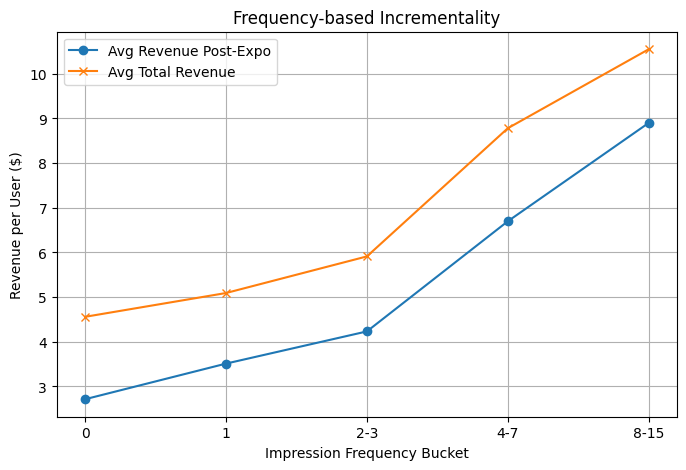

In [9]:
# ==============================
# FREQUENCY-BASED INCREMENTALITY
# ==============================
print("Computing frequency-based incrementality...")

# Define impression frequency buckets
# Adjust bins according to your data distribution
bins = [0, 1, 3, 7, 15, 1000, 100000]  # 0, 1, 2–3, 4–7, 8–15, 16+
labels = ['0', '1', '2-3', '4-7', '8-15', '16+']

user_metrics['freq_bucket'] = pd.cut(
    user_metrics['nb_impressions'],
    bins=bins,
    labels=labels,
    right=True
)

# Compute metrics per frequency bucket
freq_summary = user_metrics.groupby('freq_bucket').agg(
    users=('customer_id', 'count'),
    avg_revenue_post_expo=('sales_post_expo', 'mean'),
    conversion_rate_post_expo=('sales_post_expo', lambda x: (x > 0).mean() * 100),
    avg_spend=('budget_media', 'mean'),
    avg_total_revenue=('sales_total', 'mean')
).reset_index()

# Sort buckets logically
freq_summary['freq_bucket'] = pd.Categorical(freq_summary['freq_bucket'], categories=labels, ordered=True)
freq_summary = freq_summary.sort_values('freq_bucket')

# Display summary
print(freq_summary)

# Optional: plot revenue vs frequency
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.plot(freq_summary['freq_bucket'], freq_summary['avg_revenue_post_expo'], marker='o', label='Avg Revenue Post-Expo')
    plt.plot(freq_summary['freq_bucket'], freq_summary['avg_total_revenue'], marker='x', label='Avg Total Revenue')
    plt.xlabel('Impression Frequency Bucket')
    plt.ylabel('Revenue per User ($)')
    plt.title('Frequency-based Incrementality')
    plt.grid(True)
    plt.legend()
    plt.show()
except ImportError:
    pass